#Тестовое задание "Задача по анализу поиска в Яндекс Картинках"

##Задачи:
1. Укажите даты диапазона, предоставленного вам для анализа?
2. Рассчитайте количество запросов с текстом "ютуб" в каждой платформе (desktop, touch)
3. Выведите топ-10 самых частотных запросов в каждой платформе (desktop, touch). Какие отличия вы видите?
4. Посмотрите, чем отличается трафик запросов в течение дня. Как можно объяснить отличие?
5. Выделите тематики запросов, контрастные для мобильных и компьютеров - темы, доля которых отличаются на разных платформах

In [3]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import pandasql as ps
from pandasql import sqldf


df = pd.read_csv('data.tsv', sep='\t', header=None, names=['query', 'time', 'platform'])

df["date"] = pd.to_datetime(ps.sqldf("SELECT datetime(time, 'unixepoch', '+0 hours') as date FROM df")["date"])
df.head(10)



,query,time,platform,date
0,малевич картины,1631806465,desktop,2021-09-16 15:34:25
1,психология,1631781583,touch,2021-09-16 08:39:43
2,с днём рождения лена,1631771563,touch,2021-09-16 05:52:43
3,зверополис фильмы,1631787599,touch,2021-09-16 10:19:59
4,алабай собака фото,1631786645,touch,2021-09-16 10:04:05
5,бактериофаг,1631816202,desktop,2021-09-16 18:16:42
6,полина гагарина,1631804005,touch,2021-09-16 14:53:25
7,кадр из фильма,1631770837,desktop,2021-09-16 05:40:37
8,погода,1631780741,touch,2021-09-16 08:25:41
9,кухни дизайн,1631813821,touch,2021-09-16 17:37:01


##Задача №1

Укажите даты диапазона, предоставленного вам для анализа

In [4]:
min_date = df['date'].min()
max_date = df['date'].max()

print(f"\nДиапазон дат: с {min_date} по {max_date}")


Диапазон дат: с 2021-08-31 21:00:00 по 2021-09-21 20:59:59


In [5]:
print(ps.sqldf("""
    SELECT 'Диапазон дат: с ' || STRFTIME('%d.%m.%Y %H:%M:%S', DATE(MIN(date))) || ' по ' || STRFTIME('%d.%m.%Y %H:%M:%S', DATE(MAX(date))) as result
    FROM df
    ORDER BY time
    DESC
    LIMIT 1
""")['result'][0])

Диапазон дат: с 31.08.2021 00:00:00 по 21.09.2021 00:00:00


##Задача №2

Рассчитайте количество запросов с текстом "ютуб" в каждой платформе (desktop, touch)

Поиск осуществляется с учетом регистра букв

In [6]:
def count_youtube(platform_name):
    platform_df = df[df['platform'] == platform_name]
    mask = platform_df['query'].str.contains('ютуб', na=False)
    count = mask.sum()
    return count

youtube_desktop = count_youtube('desktop')
youtube_touch = count_youtube('touch')

print(f"Количество запросов с 'ютуб' на desktop: {youtube_desktop}")
print(f"Количество запросов с 'ютуб' на touch: {youtube_touch}")

Количество запросов с 'ютуб' на desktop: 802
Количество запросов с 'ютуб' на touch: 597


In [7]:
youtube_stats = ps.sqldf(f"""
    SELECT platform, COUNT(*) as count
    FROM df
    WHERE query LIKE '%ютуб%'
    GROUP BY platform
""")

youtube_stats.to_csv('youtube_stats.csv', index=False, encoding='utf-8-sig')

youtube_stats

,platform,count
0,desktop,802
1,touch,597


##Задача №3

Выведите топ-10 самых частотных запросов в каждой платформе (desktop, touch). Какие отличия вы видите?

In [8]:
def get_top_10(platform_name):
    platform_df = df[df['platform'] == platform_name]
    top_queries = platform_df['query'].value_counts().head(10).reset_index()
    top_queries.columns = ['Запрос', 'Количество']
    return top_queries

print("Топ-10 запросов на desktop:")
print(get_top_10('desktop'))
print("\nТоп-10 запросов на touch:")
print(get_top_10('touch'))

Топ-10 запросов на desktop:
                            Запрос  Количество
0                   календарь 2021        2804
1               таблица менделеева        2631
2                         картинки        1647
3               английский алфавит        1293
4             обои на рабочий стол        1143
5  Одноклассники (социальная сеть)        1116
6                таблица квадратов         877
7                          алфавит         874
8                таблица умножения         867
9                       карта мира         795

Топ-10 запросов на touch:
                    Запрос  Количество
0  с днём рождения женщине        4903
1          с днём рождения        3967
2  с днём рождения мужчине        3623
3          с днем рождения        3005
4                   погода        2840
5                     игры        2833
6                   фильмы        2746
7                  новости        2708
8                   музыка        2696
9                     мода        2648

In [9]:
desktop_top = ps.sqldf("""
    SELECT query AS Запрос, COUNT(*) AS Количество
    FROM df
    WHERE platform = 'desktop'
    GROUP BY query
    ORDER BY Количество DESC
    LIMIT 10
""")

print("Топ-10 на desktop (SQL):")
desktop_top

Топ-10 на desktop (SQL):


,Запрос,Количество
0,календарь 2021,2804
1,таблица менделеева,2631
2,картинки,1647
3,английский алфавит,1293
4,обои на рабочий стол,1143
5,Одноклассники (социальная сеть),1116
6,таблица квадратов,877
7,алфавит,874
8,таблица умножения,867
9,карта мира,795


In [10]:
touch_top = ps.sqldf("""
    SELECT query AS Запрос, COUNT(*) AS Количество
    FROM df
    WHERE platform = 'touch'
    GROUP BY query
    ORDER BY Количество DESC
    LIMIT 10
""")

print("Топ-10 на touch (SQL):")
touch_top

Топ-10 на touch (SQL):


,Запрос,Количество
0,с днём рождения женщине,4903
1,с днём рождения,3967
2,с днём рождения мужчине,3623
3,с днем рождения,3005
4,погода,2840
5,игры,2833
6,фильмы,2746
7,новости,2708
8,музыка,2696
9,мода,2648


In [11]:
desktop_top = get_top_10('desktop')
touch_top = get_top_10('touch')

desktop_top['platform'] = 'desktop'
touch_top['platform'] = 'touch'

top_queries_all = pd.concat([desktop_top, touch_top])
top_queries_all.to_csv('top_10_queries.csv', index=False, encoding='utf-8-sig')

###Анализ полученных данных:

На устройствах desktop большинство запросов связано с поиском рабочих инструментов, которые применяются на работе или в учебе.
На устройствах touch большиство запросов связано с развлечениями, досугом, поздравлениями.

##Задача №4

Посмотрите, чем отличается трафик запросов в течение дня. Как можно объяснить отличие?

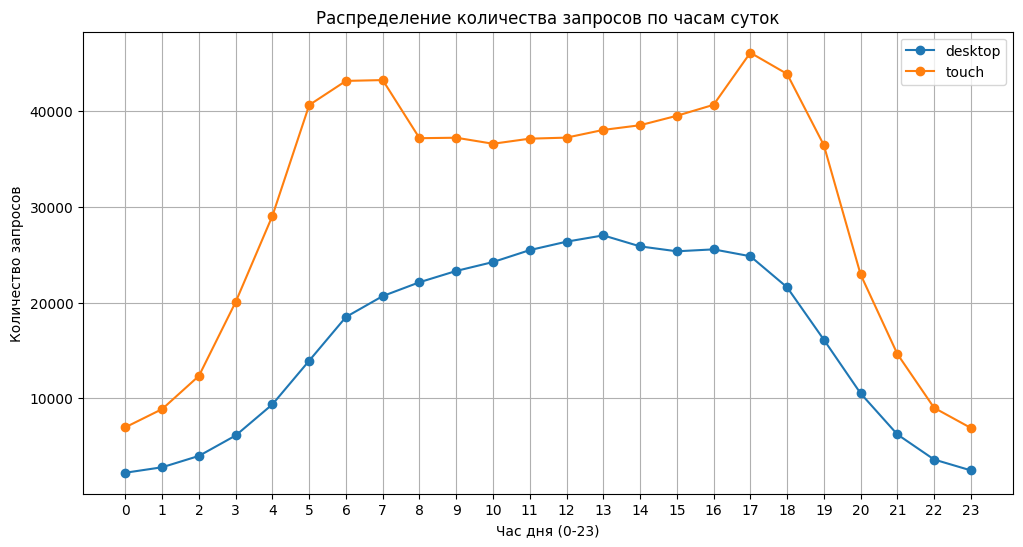

In [12]:
df['hour'] = df['date'].dt.hour
hourly_traffic = df.groupby(['hour', 'platform']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))

for platform in ['desktop', 'touch']:
    platform_data = hourly_traffic[hourly_traffic['platform'] == platform]
    plt.plot(platform_data['hour'], platform_data['count'], marker='o', label=platform)

plt.title('Распределение количества запросов по часам суток')
plt.xlabel('Час дня (0-23)')
plt.ylabel('Количество запросов')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.show()

Данные из SQL запроса:
   hour platform  count
0     0  desktop   2234
1     0    touch   6981
2     1  desktop   2805
3     1    touch   8881
4     2  desktop   3989
5     2    touch  12343
6     3  desktop   6122
7     3    touch  20066
8     4  desktop   9375
9     4    touch  29063


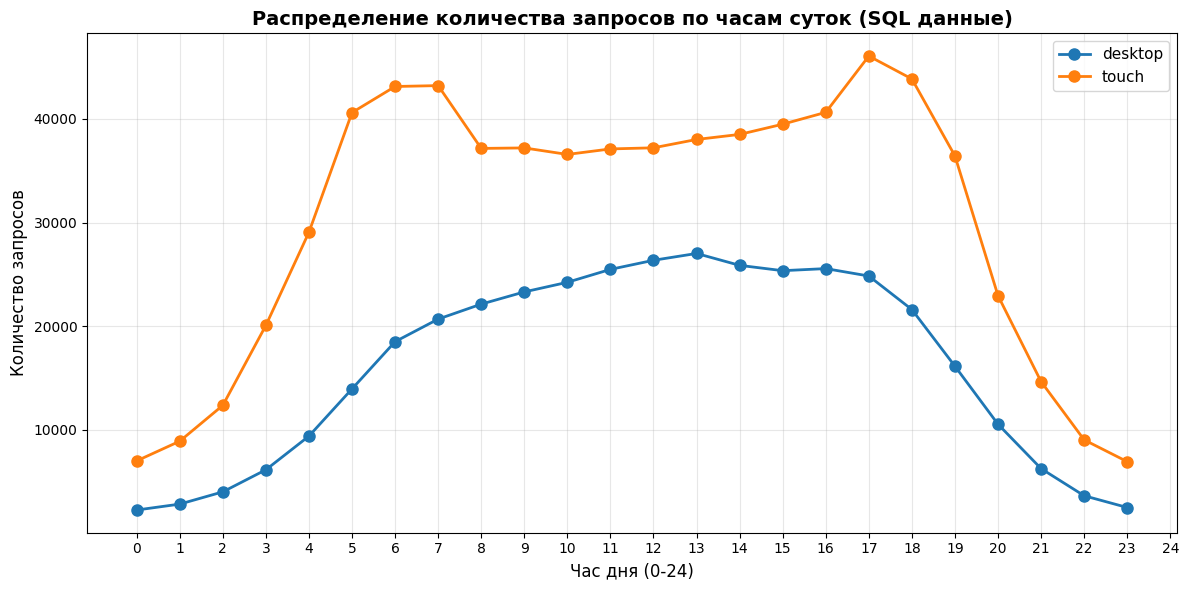

In [ ]:
query_hourly = """
SELECT 
    CAST(strftime('%H', date) AS INTEGER) as hour,
    platform,
    COUNT(*) as count
FROM df
GROUP BY hour, platform
ORDER BY hour, platform
"""

# Выполняем SQL запрос
hourly_traffic_sql = ps.sqldf(query_hourly, globals())

print("Данные из SQL запроса:")
print(hourly_traffic_sql.head(10))

# Строим график
plt.figure(figsize=(12, 6))

for platform in ['desktop', 'touch']:
    platform_data = hourly_traffic_sql[hourly_traffic_sql['platform'] == platform]
    plt.plot(platform_data['hour'], platform_data['count'], 
             marker='o', linewidth=2, markersize=8, label=platform)

plt.title('Распределение количества запросов по часам суток (SQL данные)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Час дня (0-23)', fontsize=12)
plt.ylabel('Количество запросов', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

hourly_traffic.to_csv('hourly_activity.csv', index=False, encoding='utf-8-sig')

###Анализ полученных данных:

Пики активности на мобильных устройствах (touch) утром (с 5 до 7 часоа) и вечером (с 17 до 19 часов), так как люди едут на работу или в школу/институт и в дороге пользуются мобильным устройством, а на компьютерах (desktop) — в дневное время (с 8 до 18 часов), для решения рабочих и учебных задач. Ночью трафик уменьшается, так как люди спят. Также можно заметить, что после 13 часов активность пользователей на desktop начинает снижаться, можно предположить, что это связано с усталостью и снижением уровня концентрации на рабочих задачах

##Задача №5

 Выделите тематики запросов, контрастные для мобильных и компьютеров - темы, доля которых отличаются на разных платформах

 Распределение тематик по платформам:
           topic platform   count     share
0         другое  desktop  307471  0.791912
1    образование  desktop   27199  0.070053
2           обои  desktop   13376  0.034451
3    развлечения  desktop   12951  0.033356
4        соцсети  desktop    7158  0.018436
5          аниме  desktop    6615  0.017037
6   поздравления  desktop    5514  0.014202
7       животные  desktop    3696  0.009519
8           дети  desktop    1091  0.002810
9         погода  desktop    1087  0.002800
10           еда  desktop    1069  0.002753
11       новости  desktop     799  0.002058
12      медицина  desktop     238  0.000613
13        другое    touch  540911  0.744953
14  поздравления    touch   53279  0.073377
15   развлечения    touch   48571  0.066893
16   образование    touch   22898  0.031536
17          обои    touch   17769  0.024472
18         аниме    touch   10860  0.014957
19      животные    touch    6930  0.009544
20        погода    touch    5542  0.0

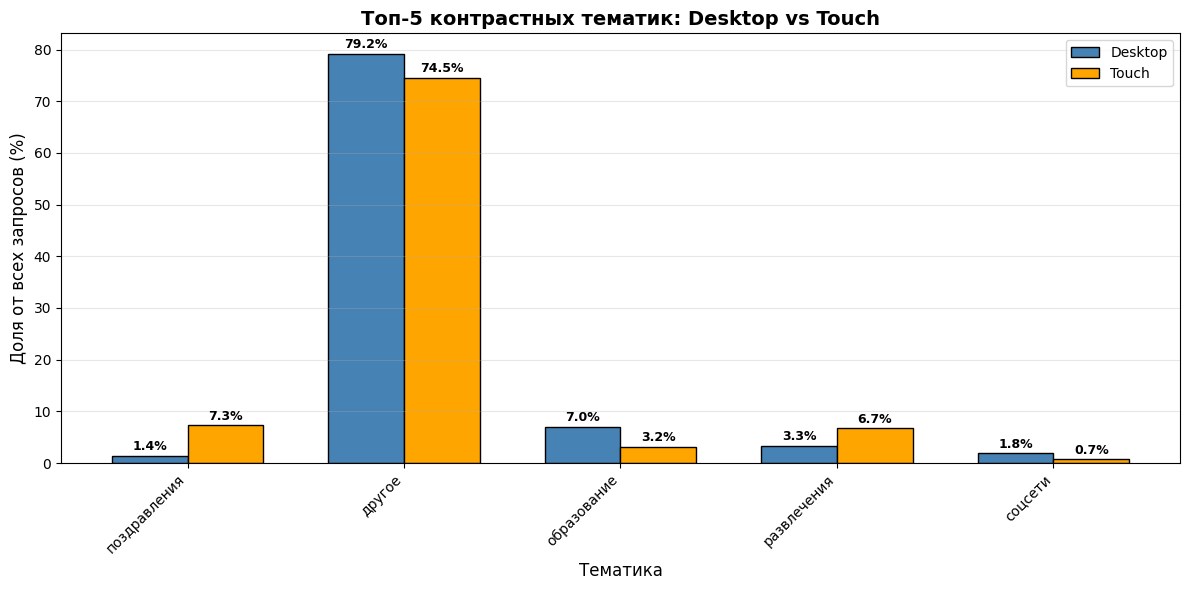

 АНАЛИЗ КОНТРАСТНЫХ ТЕМАТИК:

🔸 ПОЗДРАВЛЕНИЯ:
   Desktop: 1.42%
   Touch:   7.34%
   Разница: 5.92% (больше на Touch)

🔸 ДРУГОЕ:
   Desktop: 79.19%
   Touch:   74.50%
   Разница: 4.70% (больше на Desktop)

🔸 ОБРАЗОВАНИЕ:
   Desktop: 7.01%
   Touch:   3.15%
   Разница: 3.85% (больше на Desktop)

🔸 РАЗВЛЕЧЕНИЯ:
   Desktop: 3.34%
   Touch:   6.69%
   Разница: 3.35% (больше на Touch)

🔸 СОЦСЕТИ:
   Desktop: 1.84%
   Touch:   0.74%
   Разница: 1.10% (больше на Desktop)


In [14]:
df_clean = df.copy()
df_clean['query'] = df_clean['query'].str.lower().str.strip()

topics = [
    ['поздравления', ['с днём рождения', 'с днем рождения', 'поздравление', 'юбилей']],
    ['образование', ['таблица', 'алфавит', 'карта мира', 'календарь', 'формула', 'дискриминант']],
    ['соцсети', ['одноклассники', 'вконтакте', 'вк', 'ютуб', 'youtube', 'телеграм', 'whatsapp']],
    ['развлечения', ['игры', 'фильмы', 'музыка', 'мемы', 'приколы', 'смешные','мода','картинки','images']],
    ['обои', ['обои', 'фон', 'wallpaper']],
    ['погода', ['погода', 'температура', 'дождь']],
    ['новости', ['новости', 'новость']],
    ['животные', ['кот', 'собака', 'котик', 'животные', 'звери']],
    ['еда', ['рецепт', 'еда', 'готовка', 'кулинария']],
    ['аниме', ['аниме', 'геншин', 'anime', 'genshin', 'наруто']],
    ['дети', ['дети', 'детям', 'ребенок', 'сказки', 'загадки']],
    ['медицина', ['болезнь', 'болезни', 'лечение', 'лекарство', 'таблетки', 'медицина']],
]

df_clean['topic'] = 'другое'
for topic_name, keywords in topics:
    for keyword in keywords:
        df_clean.loc[df_clean['query'].str.contains(keyword, na=False), 'topic'] = topic_name

topic_distribution = ps.sqldf("""
    SELECT 
        topic,
        platform,
        COUNT(*) as count,
        COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY platform) as share
    FROM df_clean
    GROUP BY topic, platform
    ORDER BY platform, share DESC
""")

print(" Распределение тематик по платформам:")
print(topic_distribution)

topic_pivot = topic_distribution.pivot(index='topic', columns='platform', values='share').fillna(0)
topic_pivot['contrast'] = abs(topic_pivot.get('desktop', 0) - topic_pivot.get('touch', 0))
topic_pivot['dominant_platform'] = topic_pivot.apply(
    lambda row: 'desktop' if row.get('desktop', 0) > row.get('touch', 0) else 'touch', axis=1
)

contrast_themes = topic_pivot.sort_values('contrast', ascending=False)

print(" ТОП-10 КОНТРАСТНЫХ ТЕМАТИК:")
print(contrast_themes[['desktop', 'touch', 'contrast', 'dominant_platform']].head(10).round(4))

top_contrast = contrast_themes.head(5)

plt.figure(figsize=(12, 6))
x = range(len(top_contrast))
width = 0.35

plt.bar([i - width/2 for i in x], top_contrast['desktop'] * 100, width, 
        label='Desktop', color='steelblue', edgecolor='black')
plt.bar([i + width/2 for i in x], top_contrast['touch'] * 100, width, 
        label='Touch', color='orange', edgecolor='black')

plt.xlabel('Тематика', fontsize=12)
plt.ylabel('Доля от всех запросов (%)', fontsize=12)
plt.title('Топ-5 контрастных тематик: Desktop vs Touch', fontsize=14, fontweight='bold')
plt.xticks(x, top_contrast.index, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

for i, (desk, touch) in enumerate(zip(top_contrast['desktop'], top_contrast['touch'])):
    plt.text(i - width/2, desk*100 + 0.5, f'{desk*100:.1f}%', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(i + width/2, touch*100 + 0.5, f'{touch*100:.1f}%', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(" АНАЛИЗ КОНТРАСТНЫХ ТЕМАТИК:")
print("=" * 70)
for topic, row in contrast_themes.head(5).iterrows():
    desk_pct = row['desktop'] * 100
    touch_pct = row['touch'] * 100
    diff = abs(desk_pct - touch_pct)
    winner = "Desktop" if desk_pct > touch_pct else "Touch"
    
    print(f"\n🔸 {topic.upper()}:")
    print(f"   Desktop: {desk_pct:.2f}%")
    print(f"   Touch:   {touch_pct:.2f}%")
    print(f"   Разница: {diff:.2f}% (больше на {winner})")

topic_distribution.to_csv('topic_distribution.csv', index=False, encoding='utf-8-sig')